### 주가예측 모델(GRU)

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

In [ ]:
# 1. 데이터 수집
ticker = "AAPL"  # 애플 주식
data = yf.download(ticker, start="2015-01-01", end="2024-01-01")
data = data[['Close']]  # 종가 데이터만 사용

[*********************100%***********************]  1 of 1 completed


In [ ]:
# 2. 데이터 전처리
scaler = MinMaxScaler(feature_range=(0, 1))  # 데이터를 0~1 사이로 정규화
scaled_data = scaler.fit_transform(data)

In [ ]:
# GRU 모델에 적합한 데이터셋 생성 함수
def create_dataset(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:i + look_back, 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

In [ ]:
look_back = 60  # 과거 60일 데이터로 예측
X, y = create_dataset(scaled_data, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))  # GRU 입력 형태

In [ ]:
# 3. GRU 모델 구성
model = Sequential([
    GRU(50, return_sequences=True, input_shape=(X.shape[1], 1)),
    GRU(50),
    Dense(1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
# 4. 모델 학습
train_size = int(len(X) * 0.8)  # 80% 학습 데이터, 20% 테스트 데이터
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), shuffle=False)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - loss: 0.0408 - val_loss: 7.2451e-04
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 2.5217e-04 - val_loss: 5.3749e-04
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 1.4906e-04 - val_loss: 5.6741e-04
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 1.6695e-04 - val_loss: 4.6104e-04
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - loss: 1.4854e-04 - val_loss: 5.0091e-04
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - loss: 1.6029e-04 - val_loss: 4.1404e-04
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 1.2185e-04 - val_loss: 5.2404e-04
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 1.4006e-04 - val_loss: 3.7142e-04
Epoch 9/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 1.1489e-04 - val_loss: 4.8070e-04
Epoch 10/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 1.2394e-04 - val_loss: 4.1188e-04
Epoch 11/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 1.0895e-04 

In [ ]:
# 5. 예측
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))  # 정규화 복원

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


In [ ]:
# 실제 값 복원
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

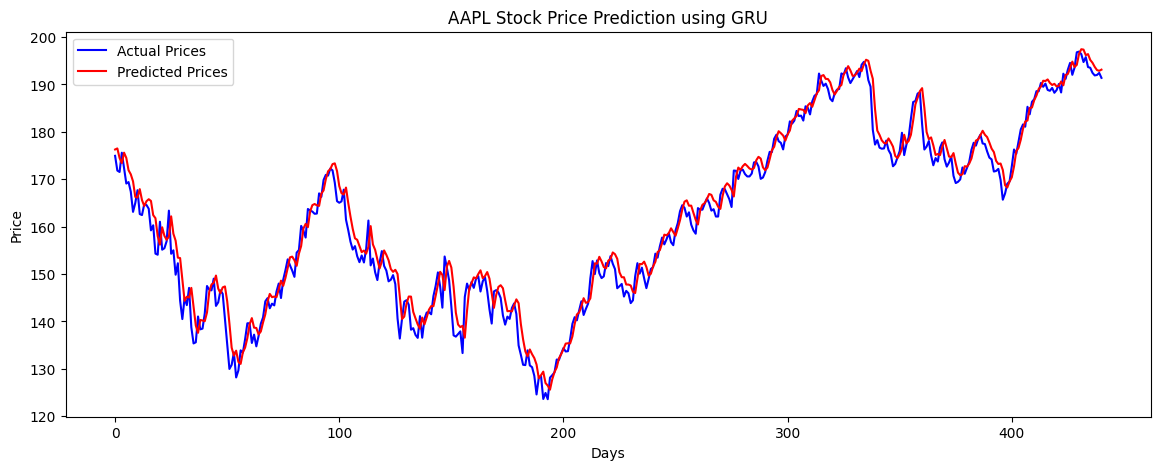

In [ ]:
# 6. 시각화
plt.figure(figsize=(14, 5))
plt.plot(actual_prices, label="Actual Prices", color='blue')
plt.plot(predictions, label="Predicted Prices", color='red')
plt.title(f'{ticker} Stock Price Prediction using GRU')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()